# 01 — Data Exploration

**Goal:** Understand the raw and processed OHLCV data for Nifty 50 instruments.

Questions answered:
1. What does the data look like? (shape, dtypes, date range)
2. Are there missing values or gaps?
3. What is the typical ATR for each instrument?
4. What does the price, volume, and return distribution look like?
5. Are there outliers or data quality issues?
6. What does a candlestick chart look like?

**Pre-requisites — run from ZoneTrend/ root:**
```bash
pip install yfinance pandas numpy matplotlib mplfinance pyyaml
python src/data/fetch_data.py --mode dev
python src/data/preprocessor.py --mode dev
```

In [47]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  # notebooks/ -> ZoneTrend/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/sachinchoudhary/Desktop/RI/ZoneTrend


In [48]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import mplfinance as mpf
import yaml

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 30)

from src.data.data_loader import DataLoader
print('Imports OK')

Imports OK


In [49]:
with open(PROJECT_ROOT / 'config' / 'config.yaml') as f:
    import yaml; cfg = yaml.safe_load(f)
DEV_SYMBOLS = cfg['data']['dev_symbols']
print(f'Dev symbols ({len(DEV_SYMBOLS)}): {DEV_SYMBOLS}')

Dev symbols (9): ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'ICICIBANK.NS', 'SBIN.NS', 'APOLLOHOSP.NS', 'SUNPHARMA.NS', '^NSEI']


---
## 1. Load Raw and Processed Data

In [50]:
raw_loader = DataLoader(source='raw')
raw_data   = raw_loader.load_all(mode='dev')
print(f'Raw data — {len(raw_data)} symbols:')
for sym, df in raw_data.items():
    print(f'  {sym:20s} | {len(df):5d} rows | {df.index.min().date()} to {df.index.max().date()}')

Raw data — 9 symbols:
  RELIANCE.NS          |  5544 rows | 2004-01-01 to 2026-05-29
  TCS.NS               |  5545 rows | 2004-01-01 to 2026-05-29
  HDFCBANK.NS          |  5546 rows | 2004-01-01 to 2026-05-29
  INFY.NS              |  5546 rows | 2004-01-01 to 2026-05-29
  ICICIBANK.NS         |  5543 rows | 2004-01-01 to 2026-05-29
  SBIN.NS              |  5543 rows | 2004-01-01 to 2026-05-29
  APOLLOHOSP.NS        |  5544 rows | 2004-01-01 to 2026-05-29
  SUNPHARMA.NS         |  5545 rows | 2004-01-01 to 2026-05-29
  ^NSEI                |  4585 rows | 2007-09-17 to 2026-05-29


In [51]:
proc_loader = DataLoader(source='processed')
proc_data   = proc_loader.load_all(mode='dev')
print(f'Processed data — {len(proc_data)} symbols:')
for sym, df in proc_data.items():
    print(f'  {sym:20s} | {len(df):5d} rows | {len(df.columns)} columns')

Processed data — 9 symbols:
  RELIANCE.NS          |  5544 rows | 28 columns
  TCS.NS               |  5545 rows | 28 columns
  HDFCBANK.NS          |  5546 rows | 28 columns
  INFY.NS              |  5546 rows | 28 columns
  ICICIBANK.NS         |  5543 rows | 28 columns
  SBIN.NS              |  5543 rows | 28 columns
  APOLLOHOSP.NS        |  5544 rows | 28 columns
  SUNPHARMA.NS         |  5545 rows | 28 columns
  ^NSEI                |  4585 rows | 28 columns


---
## 2. Inspect a Single Stock in Detail

In [52]:
FOCUS = 'RELIANCE.NS'
df = proc_data[FOCUS]
print(f'Shape: {df.shape}')
print(f'Date range: {df.index.min().date()} to {df.index.max().date()}')
df.head()

Shape: (5544, 28)
Date range: 2004-01-01 to 2026-05-29


,Open,High,Low,Close,Volume,TrueRange,ATR,IsOutlier,LogReturn,RollingVolatility,CandleBody,UpperWick,LowerWick,CandleRange,IsBullish,BodyRatio,UpperWickRatio,LowerWickRatio,BodyToATR,RangeToATR,SMA20,EMA20,SMA50,EMA50,SMA200,EMA200,VolumeMA20,VolumeRatio
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2004-01-01,34.10,34.10,33.35,33.55,57015472,0.76,NaN,0,NaN,NaN,0.55,0.00,0.21,0.76,0,0.73,0.00,0.27,NaN,NaN,NaN,33.55,NaN,33.55,NaN,33.55,NaN,NaN
2004-01-02,33.78,34.63,33.55,34.41,113656354,1.07,NaN,0,0.03,NaN,0.63,0.22,0.23,1.07,1,0.59,0.20,0.21,NaN,NaN,NaN,33.63,NaN,33.59,NaN,33.56,NaN,NaN
2004-01-05,34.40,34.68,33.63,34.11,85438299,1.05,NaN,0,-0.01,NaN,0.29,0.29,0.47,1.05,0,0.28,0.27,0.45,NaN,NaN,NaN,33.68,NaN,33.61,NaN,33.57,NaN,NaN
2004-01-06,34.16,34.60,33.16,33.66,81160289,1.44,NaN,0,-0.01,NaN,0.51,0.44,0.49,1.44,0,0.35,0.31,0.34,NaN,NaN,NaN,33.68,NaN,33.61,NaN,33.57,NaN,NaN
2004-01-07,33.53,34.25,33.34,34.11,83254466,0.91,NaN,0,0.01,NaN,0.59,0.14,0.19,0.91,1,0.64,0.15,0.21,NaN,NaN,NaN,33.72,NaN,33.63,NaN,33.57,NaN,NaN


In [53]:
print('Null counts:'); print(df.isnull().sum())

Null counts:
Open                   0
High                   0
Low                    0
Close                  0
Volume                 0
TrueRange              0
ATR                   13
IsOutlier              0
LogReturn              1
RollingVolatility     20
CandleBody             0
UpperWick              0
LowerWick              0
CandleRange            0
IsBullish              0
BodyRatio             19
UpperWickRatio        19
LowerWickRatio        19
BodyToATR             13
RangeToATR            13
SMA20                 19
EMA20                  0
SMA50                 49
EMA50                  0
SMA200               199
EMA200                 0
VolumeMA20            19
VolumeRatio           19
dtype: int64


In [54]:
df[['Open','High','Low','Close','Volume','ATR','LogReturn']].describe()

,Open,High,Low,Close,Volume,ATR,LogReturn
count,5544.00,5544.00,5544.00,5544.00,5544.00,5531.00,5543.00
mean,488.76,493.91,483.29,488.40,27470188.88,11.21,0.00
std,462.63,466.58,458.55,462.41,29793148.07,9.35,0.03
min,24.00,25.47,22.44,23.77,0.00,0.60,-1.47
25%,174.28,176.26,171.76,174.07,11872947.75,4.22,-0.01
50%,220.96,223.37,218.07,220.53,17621296.50,6.65,0.00
75%,898.25,906.78,889.09,898.03,30352088.25,18.13,0.01
max,1593.00,1611.80,1578.20,1592.30,632289604.00,38.90,1.48


---
## 3. Gap Detection

In [55]:
def find_gaps(df, symbol, threshold=5):
    diff = df.index.to_series().diff().dt.days
    gaps = diff[diff > threshold]
    print(f'{symbol} — gaps > {threshold} calendar days:')
    if gaps.empty: print('  None found.')
    else:
        for dt, g in gaps.items(): print(f'  {dt.date()}: {int(g)}-day gap')

for sym, df in proc_data.items(): find_gaps(df, sym)

RELIANCE.NS — gaps > 5 calendar days:
  2014-10-07: 6-day gap
TCS.NS — gaps > 5 calendar days:
  2014-10-07: 6-day gap
HDFCBANK.NS — gaps > 5 calendar days:
  2014-10-07: 6-day gap
INFY.NS — gaps > 5 calendar days:
  2014-10-07: 6-day gap
ICICIBANK.NS — gaps > 5 calendar days:
  2014-10-07: 6-day gap
SBIN.NS — gaps > 5 calendar days:
  2014-10-07: 6-day gap
APOLLOHOSP.NS — gaps > 5 calendar days:
  2014-10-07: 6-day gap
SUNPHARMA.NS — gaps > 5 calendar days:
  2014-10-07: 6-day gap
^NSEI — gaps > 5 calendar days:
  2014-10-07: 6-day gap


---
## 4. ATR Analysis Across All Symbols

ATR is the foundation of zone width calculations and feature normalisation.

In [56]:
rows = []
for sym, df in proc_data.items():
    if 'ATR' not in df.columns: continue
    atr = df['ATR'].dropna(); close = df['Close'].dropna()
    atr_pct = (atr / close * 100).dropna()
    rows.append({'Symbol': sym, 'ATR_Mean_INR': atr.mean(),
                 'ATR_pct_Mean': atr_pct.mean(), 'ATR_pct_Median': atr_pct.median(),
                 'Price_Latest': close.iloc[-1], 'Candles': len(df)})
atr_df = pd.DataFrame(rows).set_index('Symbol').sort_values('ATR_pct_Mean', ascending=False)
atr_df

,ATR_Mean_INR,ATR_pct_Mean,ATR_pct_Median,Price_Latest,Candles
Symbol,,,,,
APOLLOHOSP.NS,49.34,3.34,3.16,8176.50,5544
ICICIBANK.NS,9.27,3.25,2.82,1256.40,5543
SBIN.NS,7.40,3.12,2.81,964.40,5543
SUNPHARMA.NS,13.66,3.06,2.87,1799.20,5545
RELIANCE.NS,11.21,2.79,2.35,1321.20,5544
TCS.NS,27.20,2.68,2.30,2258.90,5545
HDFCBANK.NS,6.79,2.60,2.18,744.55,5546
INFY.NS,13.17,2.57,2.30,1160.90,5546
^NSEI,146.22,1.53,1.26,23547.75,4585


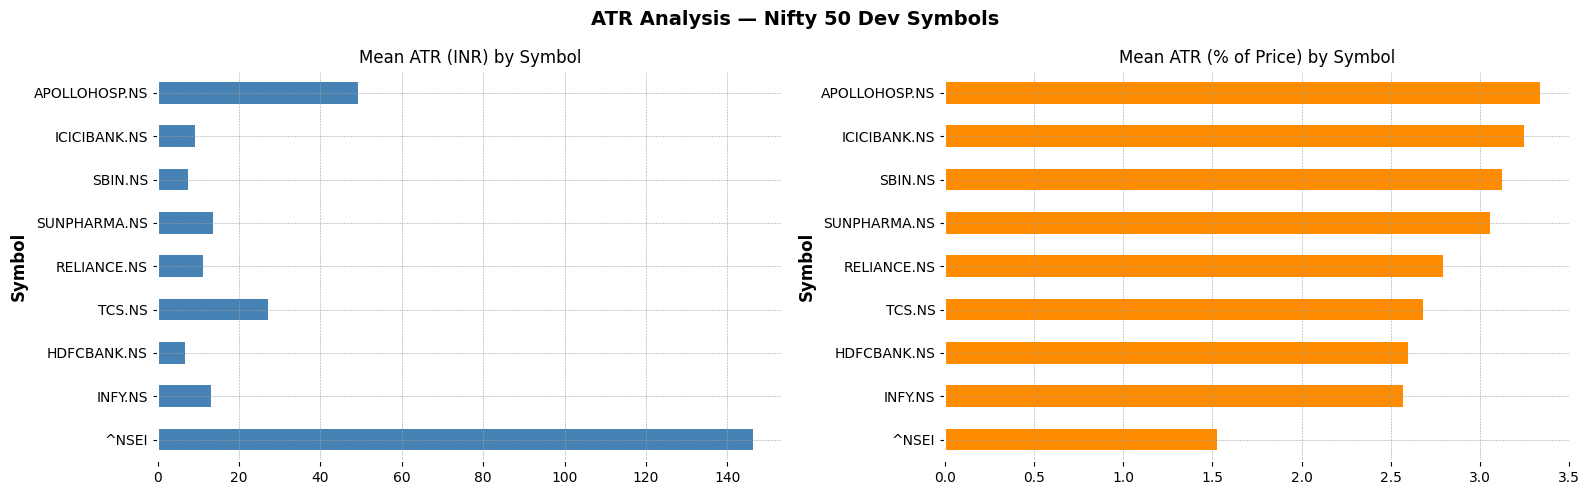

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
atr_df['ATR_Mean_INR'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Mean ATR (INR) by Symbol'); axes[0].invert_yaxis()
atr_df['ATR_pct_Mean'].plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Mean ATR (% of Price) by Symbol'); axes[1].invert_yaxis()
plt.suptitle('ATR Analysis — Nifty 50 Dev Symbols', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / 'atr_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 5. Log Return Distributions

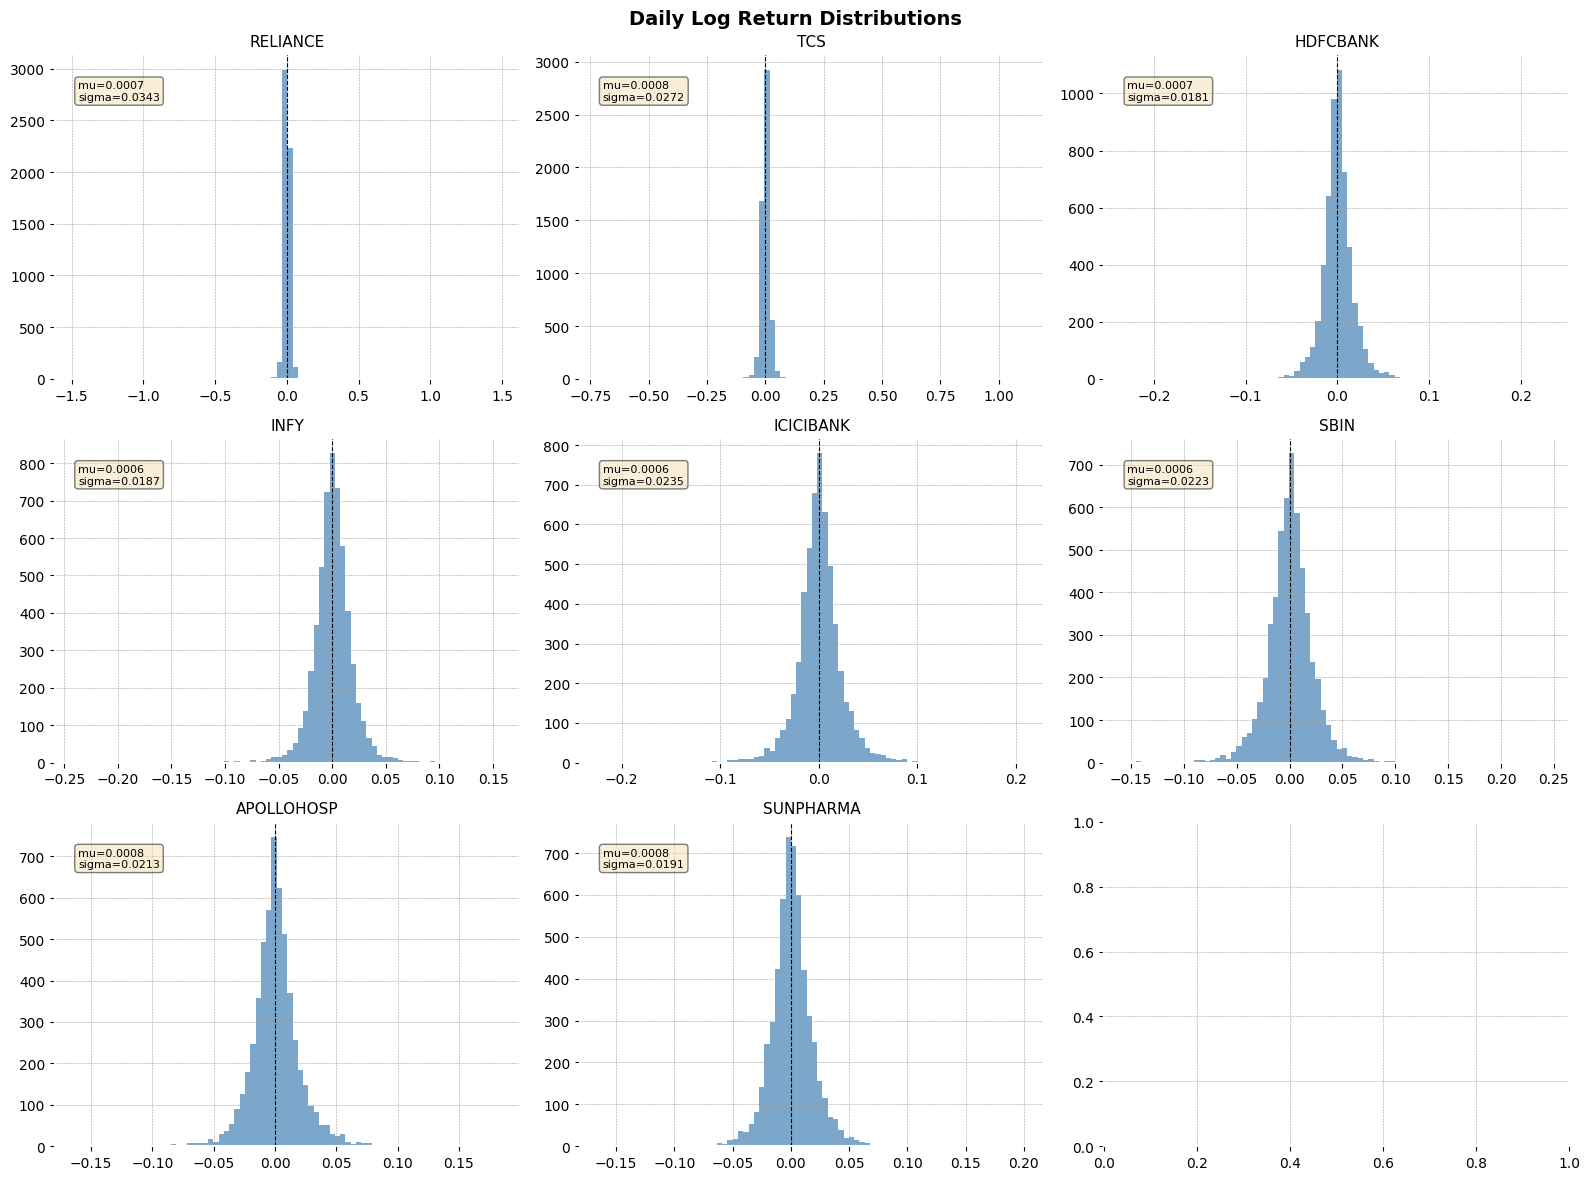

In [58]:
symbols_to_plot = [s for s in proc_data.keys() if s != '^NSEI']
fig, axes = plt.subplots(3, 3, figsize=(16, 12)); axes = axes.flatten()
for i, sym in enumerate(symbols_to_plot[:9]):
    df = proc_data[sym]; lr = df['LogReturn'].dropna()
    axes[i].hist(lr, bins=80, color='steelblue', alpha=0.7, edgecolor='none')
    axes[i].axvline(0, color='black', linestyle='--', linewidth=0.8)
    axes[i].set_title(sym.replace('.NS',''), fontsize=11)
    axes[i].text(0.05, 0.92, f'mu={lr.mean():.4f}\nsigma={lr.std():.4f}',
                 transform=axes[i].transAxes, fontsize=8, va='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.suptitle('Daily Log Return Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / 'return_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 6. ATR Over Time (Volatility Regimes)

Critical insight: zone widths must scale with ATR. A high-volatility period requires wider zones.

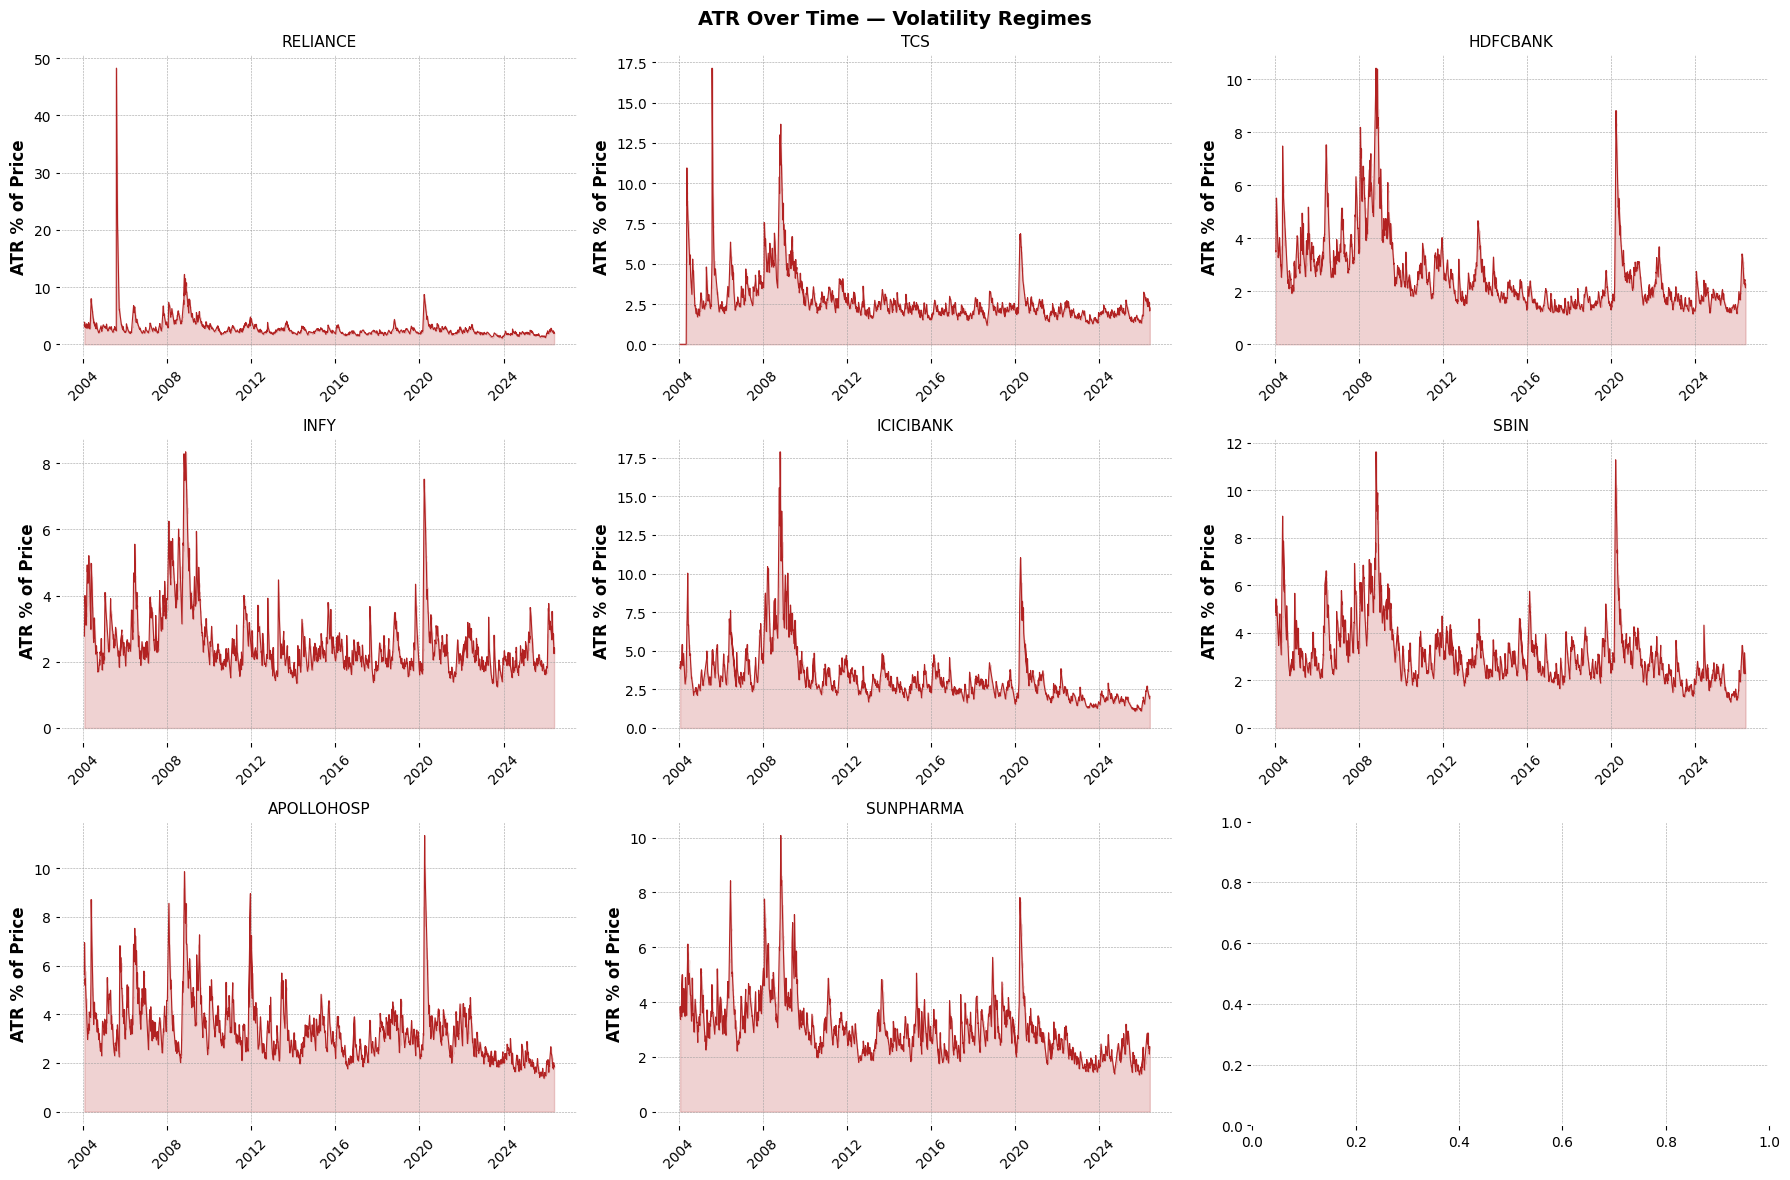

In [59]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12)); axes = axes.flatten()
for i, sym in enumerate(symbols_to_plot[:9]):
    df = proc_data[sym]
    atr_pct = (df['ATR'] / df['Close'] * 100).dropna()
    axes[i].plot(atr_pct.index, atr_pct.values, color='firebrick', linewidth=0.8)
    axes[i].fill_between(atr_pct.index, atr_pct.values, alpha=0.2, color='firebrick')
    axes[i].set_title(sym.replace('.NS',''), fontsize=11)
    axes[i].set_ylabel('ATR % of Price')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle('ATR Over Time — Volatility Regimes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / 'atr_over_time.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 7. Candle Body and Wick Analysis

These distributions inform the thresholds for candlestick pattern detection.

In [60]:
rows = []
for sym, df in proc_data.items():
    rows.append({'Symbol': sym, 'Bullish_%': df['IsBullish'].mean()*100,
                 'Avg_BodyRatio': df['BodyRatio'].mean(),
                 'Avg_UpperWick': df['UpperWickRatio'].mean(),
                 'Avg_LowerWick': df['LowerWickRatio'].mean(),
                 'Avg_BodyToATR': df['BodyToATR'].mean()})
candle_df = pd.DataFrame(rows).set_index('Symbol')
candle_df

,Bullish_%,Avg_BodyRatio,Avg_UpperWick,Avg_LowerWick,Avg_BodyToATR
Symbol,,,,,
RELIANCE.NS,47.89,0.47,0.27,0.26,0.48
TCS.NS,48.39,0.46,0.27,0.28,0.47
HDFCBANK.NS,49.46,0.44,0.27,0.29,0.45
INFY.NS,48.72,0.45,0.27,0.28,0.44
ICICIBANK.NS,47.99,0.45,0.27,0.29,0.45
SBIN.NS,47.12,0.47,0.26,0.27,0.48
APOLLOHOSP.NS,44.37,0.44,0.30,0.27,0.46
SUNPHARMA.NS,47.16,0.43,0.28,0.28,0.45
^NSEI,47.55,0.49,0.23,0.29,0.48


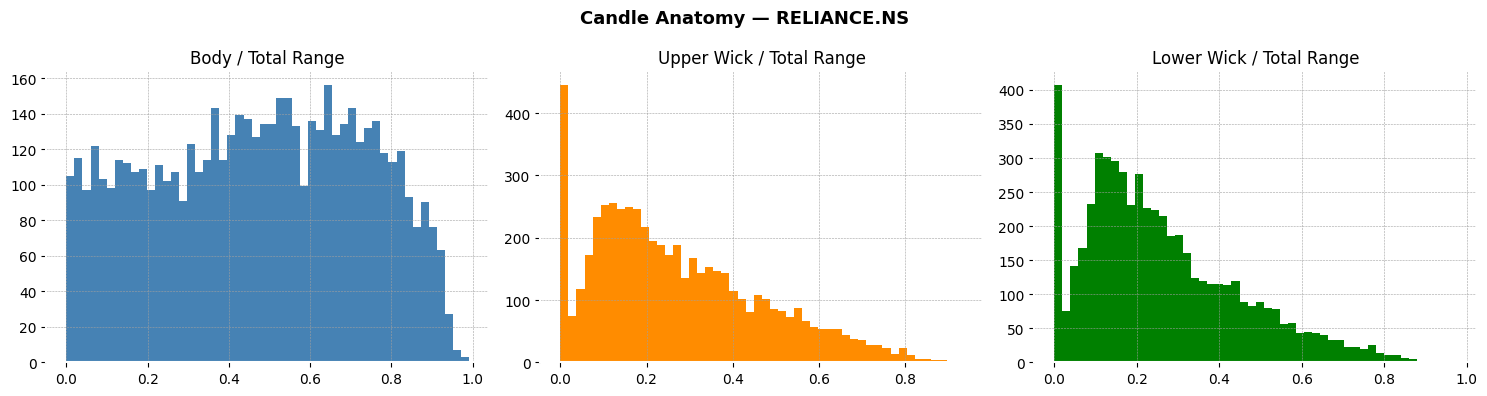

Mean body ratio = 0.47 | A hammer needs lower wick > 2x body


In [61]:
sym = 'RELIANCE.NS'; df = proc_data[sym]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['BodyRatio'].dropna().hist(bins=50, ax=axes[0], color='steelblue', edgecolor='none')
axes[0].set_title('Body / Total Range')
df['UpperWickRatio'].dropna().hist(bins=50, ax=axes[1], color='darkorange', edgecolor='none')
axes[1].set_title('Upper Wick / Total Range')
df['LowerWickRatio'].dropna().hist(bins=50, ax=axes[2], color='green', edgecolor='none')
axes[2].set_title('Lower Wick / Total Range')
plt.suptitle(f'Candle Anatomy — {sym}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / 'candle_anatomy.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Mean body ratio = {df['BodyRatio'].mean():.2f} | A hammer needs lower wick > 2x body")

---
## 8. Outlier Detection

In [62]:
print('Outlier candles (range > 5x ATR) per symbol:')
for sym, df in proc_data.items():
    n = df['IsOutlier'].sum(); pct = n/len(df)*100
    print(f'  {sym:20s} | {n:4d} ({pct:.2f}%)')

Outlier candles (range > 5x ATR) per symbol:
  RELIANCE.NS          |    6 (0.11%)
  TCS.NS               |    5 (0.09%)
  HDFCBANK.NS          |    5 (0.09%)
  INFY.NS              |    4 (0.07%)
  ICICIBANK.NS         |    2 (0.04%)
  SBIN.NS              |    3 (0.05%)
  APOLLOHOSP.NS        |    2 (0.04%)
  SUNPHARMA.NS         |    2 (0.04%)
  ^NSEI                |    2 (0.04%)


---
## 9. Candlestick Charts (Visual Validation)

Always look at the actual chart before building algorithms.

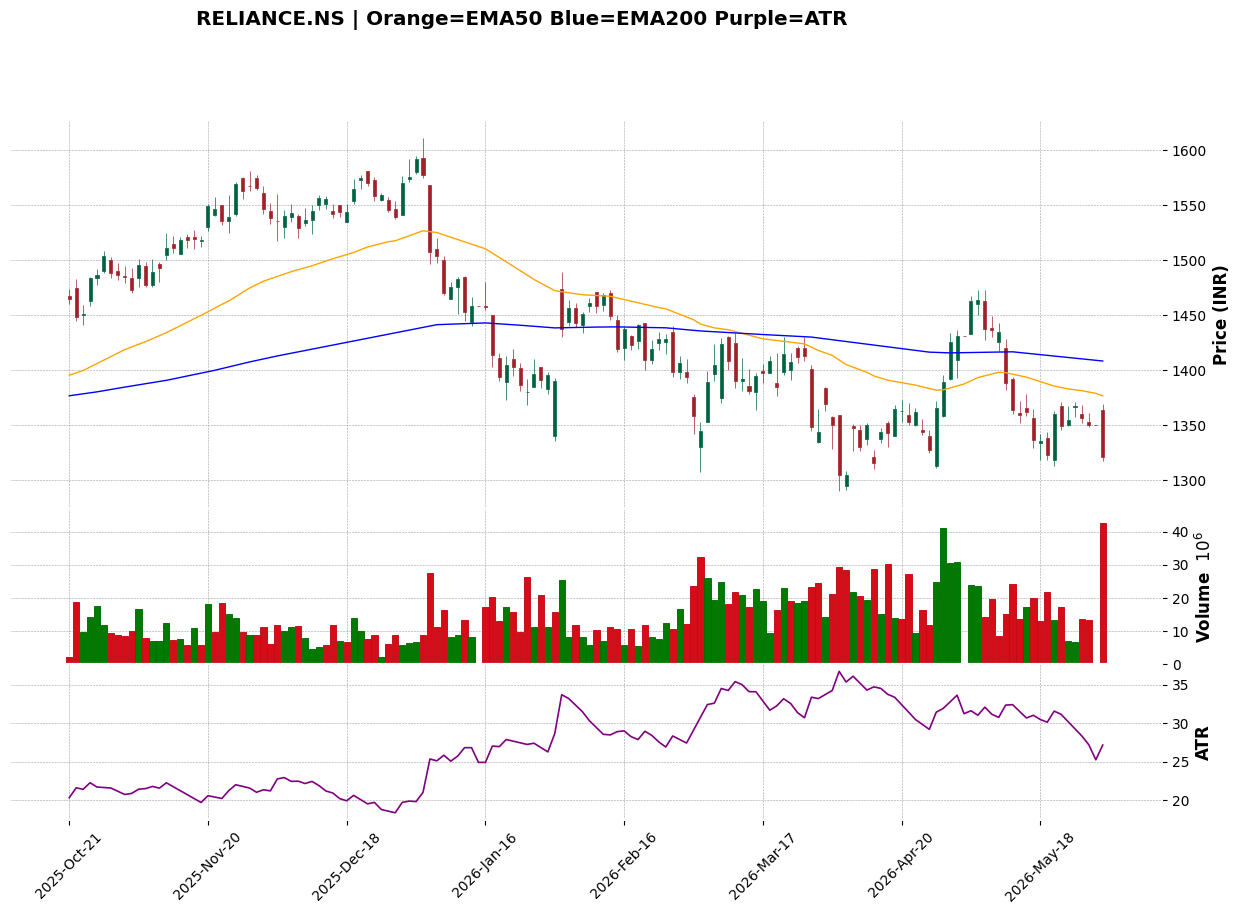

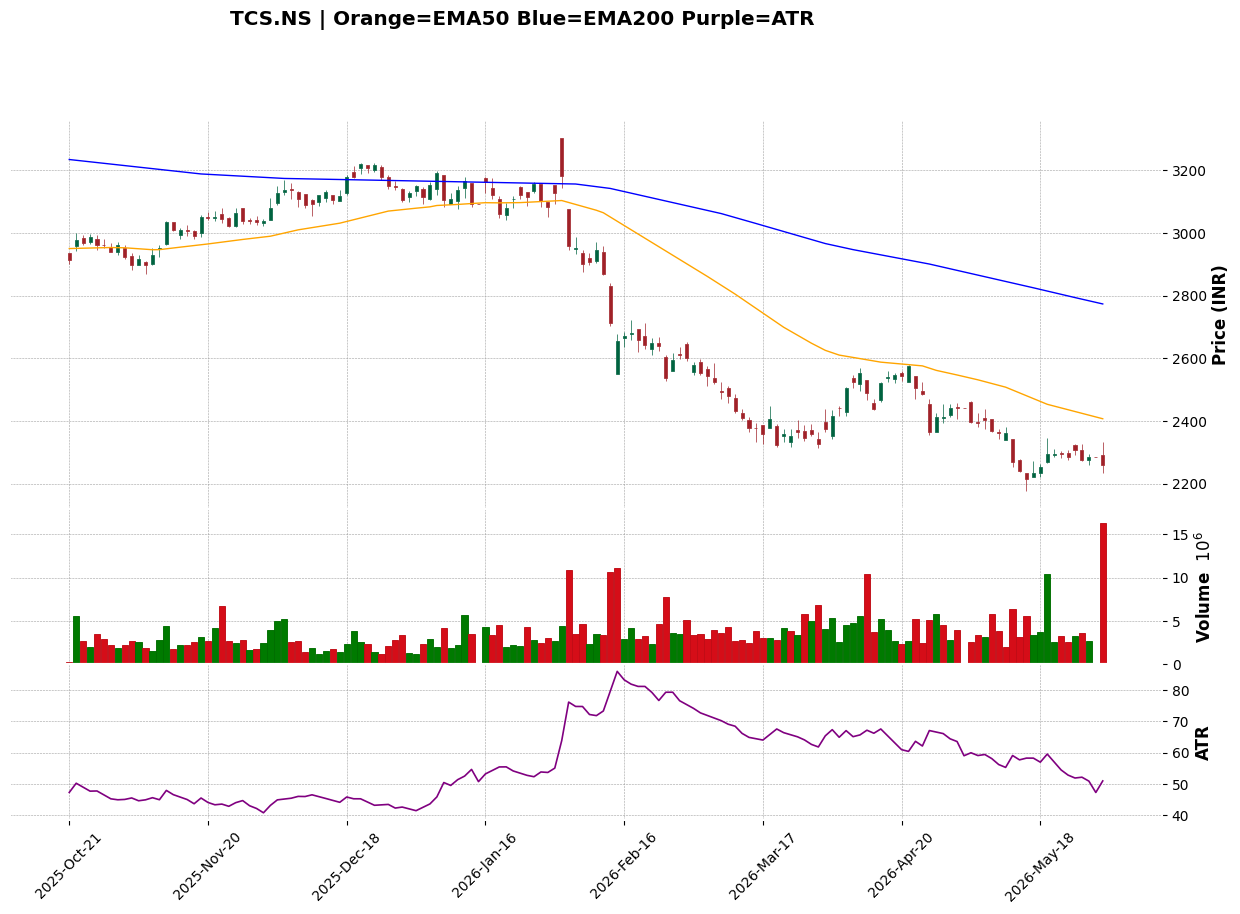

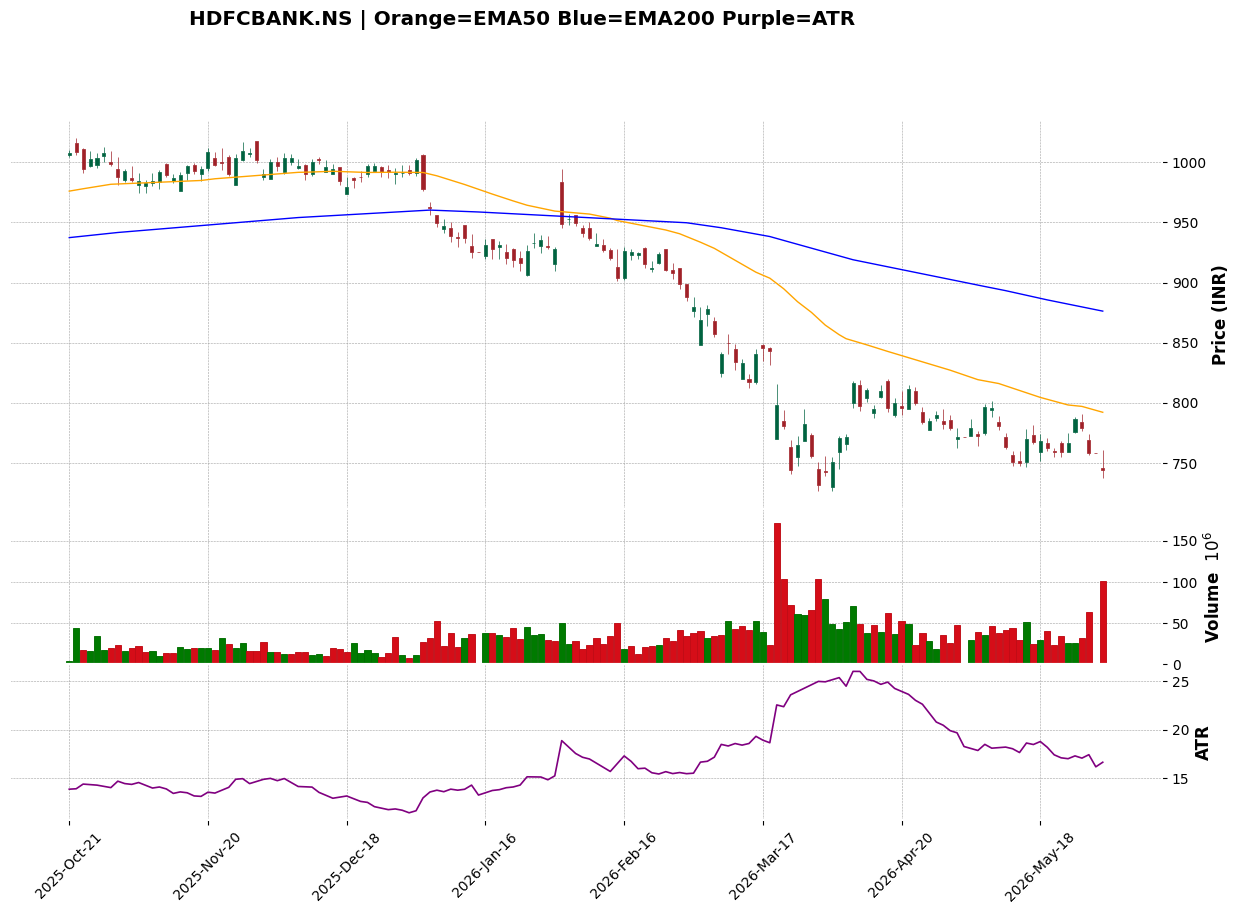

In [63]:
def plot_candlestick(symbol, df, n_candles=120):
    plot_df = df[['Open','High','Low','Close','Volume']].tail(n_candles).copy()
    ap = [
        mpf.make_addplot(df['ATR'].tail(n_candles),   panel=2, color='purple', width=1.2, ylabel='ATR'),
        mpf.make_addplot(df['EMA50'].tail(n_candles),  panel=0, color='orange', width=1.0),
        mpf.make_addplot(df['EMA200'].tail(n_candles), panel=0, color='blue',   width=1.0),
    ]
    fig, _ = mpf.plot(plot_df, type='candle', style='charles',
        title=f'{symbol} | Orange=EMA50 Blue=EMA200 Purple=ATR',
        ylabel='Price (INR)', volume=True, addplot=ap, figsize=(16,10), returnfig=True)
    safe = symbol.replace('.','_').replace('^','IDX_')
    plt.savefig(PROJECT_ROOT / 'data' / 'processed' / f'chart_{safe}.png', dpi=120, bbox_inches='tight')
    plt.show()

for sym in ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS']:
    if sym in proc_data: plot_candlestick(sym, proc_data[sym], n_candles=150)

---
## 10. Moving Average Breadth

In [64]:
rows = []
for sym, df in proc_data.items():
    last = df.iloc[-1]
    rows.append({'Symbol': sym, 'Close': last['Close'],
                 '>SMA20': last['Close']>last['SMA20'], '>SMA50': last['Close']>last['SMA50'],
                 '>SMA200': last['Close']>last['SMA200'],
                 'ATR_INR': last['ATR'], 'ATR_%': last['ATR']/last['Close']*100})
ma_df = pd.DataFrame(rows).set_index('Symbol')
ma_df

,Close,>SMA20,>SMA50,>SMA200,ATR_INR,ATR_%
Symbol,,,,,,
RELIANCE.NS,1321.20,False,False,False,27.15,2.05
TCS.NS,2258.90,False,False,False,50.96,2.26
HDFCBANK.NS,744.55,False,False,False,16.65,2.24
INFY.NS,1160.90,True,False,False,28.21,2.43
ICICIBANK.NS,1256.40,False,False,False,25.75,2.05
SBIN.NS,964.40,False,False,False,22.09,2.29
APOLLOHOSP.NS,8176.50,True,True,True,153.25,1.87
SUNPHARMA.NS,1799.20,False,True,True,42.56,2.37
^NSEI,23547.75,False,False,False,309.11,1.31


In [65]:
above = ma_df['>SMA200'].sum(); total = len(ma_df)
bias = 'Bullish' if above/total > 0.6 else ('Bearish' if above/total < 0.4 else 'Neutral')
print(f'{above}/{total} symbols above SMA200 ({above/total*100:.0f}%) — {bias} breadth')

2/9 symbols above SMA200 (22%) — Bearish breadth


---
## 11. Summary and Next Steps

In [66]:
print('='*60)
print('DATA EXPLORATION SUMMARY')
print('='*60)
total_rows = sum(len(df) for df in proc_data.values())
print(f'Symbols  : {len(proc_data)}')
print(f'Candles  : {total_rows:,}')
print()
print('ATR (% of price), mean across history:')
for sym, df in proc_data.items():
    atr_pct = (df['ATR'] / df['Close'] * 100).mean()
    print(f'  {sym:20s} | ATR ~= {atr_pct:.2f}%')
print()
print('Next steps:')
print('  1. Open 02_zone_detection_analysis.ipynb')
print('  2. Implement src/zones/swing_zones.py')
print('  3. Plot detected zones on the candlestick charts above')
print('  4. Validate zones vs manual analysis')

DATA EXPLORATION SUMMARY
Symbols  : 9
Candles  : 48,941

ATR (% of price), mean across history:
  RELIANCE.NS          | ATR ~= 2.79%
  TCS.NS               | ATR ~= 2.68%
  HDFCBANK.NS          | ATR ~= 2.60%
  INFY.NS              | ATR ~= 2.57%
  ICICIBANK.NS         | ATR ~= 3.25%
  SBIN.NS              | ATR ~= 3.12%
  APOLLOHOSP.NS        | ATR ~= 3.34%
  SUNPHARMA.NS         | ATR ~= 3.06%
  ^NSEI                | ATR ~= 1.53%

Next steps:
  1. Open 02_zone_detection_analysis.ipynb
  2. Implement src/zones/swing_zones.py
  3. Plot detected zones on the candlestick charts above
  4. Validate zones vs manual analysis
